In [1]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Confirm GPU is available
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
print(f"GPU: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'None'}")
print("All libraries imported successfully")

Device: cuda
GPU: Tesla T4
All libraries imported successfully


In [2]:
# Load metadata and build image paths
df = pd.read_csv('/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_metadata.csv')

image_dir_1 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_1'
image_dir_2 = '/kaggle/input/datasets/kmader/skin-cancer-mnist-ham10000/HAM10000_images_part_2'

image_paths = {}
for fname in os.listdir(image_dir_1):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_1, fname)
for fname in os.listdir(image_dir_2):
    image_paths[fname.replace('.jpg', '')] = os.path.join(image_dir_2, fname)

# Encode labels
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
df['label'] = le.fit_transform(df['dx'])

print(f"Classes: {list(le.classes_)}")
print(f"Total images: {len(df)}")

# Train/val/test split - 70% train, 15% val, 15% test
train_df, temp_df = train_test_split(df, test_size=0.3, random_state=42, stratify=df['label'])
val_df, test_df = train_test_split(temp_df, test_size=0.5, random_state=42, stratify=temp_df['label'])

print(f"\nTrain: {len(train_df)} | Val: {len(val_df)} | Test: {len(test_df)}")

Classes: ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']
Total images: 10015

Train: 7010 | Val: 1502 | Test: 1503


Train (70%) is what the model learns from. Validation (15%) is checked after every epoch to monitor if the model is overfitting. Test (15%) is touched only at the very end for final evaluation

In [3]:
# Custom Dataset class
class SkinLesionDataset(Dataset):
    def __init__(self, dataframe, image_paths, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.image_paths = image_paths
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = self.image_paths.get(row['image_id'])
        img = Image.open(img_path).convert('RGB')
        if self.transform:
            img = self.transform(img)
        label = row['label']
        return img, label

# Transforms - training has augmentation, val/test do not
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(20),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

val_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406],
                         [0.229, 0.224, 0.225])
])

# Create datasets
train_dataset = SkinLesionDataset(train_df, image_paths, train_transform)
val_dataset   = SkinLesionDataset(val_df,   image_paths, val_test_transform)
test_dataset  = SkinLesionDataset(test_df,  image_paths, val_test_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2)

print(f"Train batches : {len(train_loader)}")
print(f"Val batches   : {len(val_loader)}")
print(f"Test batches  : {len(test_loader)}")
print("Datasets and dataloaders ready")

Train batches : 220
Val batches   : 47
Test batches  : 47
Datasets and dataloaders ready


1) training images get augmentation while validation and testing images get no augmentation, only resizing and normalizing
2) DataLoader batches the images, instead of feeding one image at a time, it feeds 32 at once (batch_size=32)

In [4]:
# Calculate class weights to handle imbalance
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['label']),
    y=train_df['label']
)
class_weights_tensor = torch.FloatTensor(class_weights).to(device)

print("Class weights:")
for i, (cls, w) in enumerate(zip(le.classes_, class_weights)):
    print(f"  {cls:8s} → {w:.4f}")

Class weights:
  akiec    → 4.3731
  bcc      → 2.7817
  bkl      → 1.3022
  df       → 12.3633
  mel      → 1.2855
  nv       → 0.2134
  vasc     → 10.1154


class-weighted cross-entropy:- Rare classes get higher weights, common classes get lower weights. When the model makes a mistake on vasc (142 images), it gets penalized much harder than a mistake on nv (6705 images)

In [6]:
import torchvision.models as models

# Load EfficientNet-B3 without pretrained weights first
model = models.efficientnet_b3(weights=None)

# Load weights from Kaggle's local cache
import urllib.request
import os

# Use timm library instead - already installed on Kaggle
import timm

model = timm.create_model('efficientnet_b3', pretrained=True, num_classes=7)
model = model.to(device)

# Loss function with class weights
criterion = nn.CrossEntropyLoss(weight=class_weights_tensor)

# Optimizer
optimizer = optim.Adam([
    {'params': list(model.parameters())[:-2], 'lr': 1e-4},
    {'params': list(model.parameters())[-2:], 'lr': 1e-3}
])

# Scheduler
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=3, factor=0.5
)

total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters     : {total_params:,}")
print(f"Trainable parameters : {trainable_params:,}")
print(f"\nModel ready on: {device}")
print(f"Loss function: CrossEntropyLoss with class weights")
print(f"Optimizer: Adam with differential learning rates")

Total parameters     : 10,706,991
Trainable parameters : 10,706,991

Model ready on: cuda
Loss function: CrossEntropyLoss with class weights
Optimizer: Adam with differential learning rates


In [7]:
# Training loop
def train_model(model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15):
    train_losses, val_losses, train_accs, val_accs = [], [], [], []
    best_val_acc = 0.0
    
    for epoch in range(epochs):
        # Training phase
        model.train()
        train_loss, train_correct, train_total = 0, 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            train_loss += loss.item()
            _, predicted = outputs.max(1)
            train_correct += predicted.eq(labels).sum().item()
            train_total += labels.size(0)
        
        # Validation phase
        model.eval()
        val_loss, val_correct, val_total = 0, 0, 0
        
        with torch.no_grad():
            for images, labels in val_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                
                val_loss += loss.item()
                _, predicted = outputs.max(1)
                val_correct += predicted.eq(labels).sum().item()
                val_total += labels.size(0)
        
        # Calculate epoch metrics
        avg_train_loss = train_loss / len(train_loader)
        avg_val_loss   = val_loss   / len(val_loader)
        avg_train_acc  = train_correct / train_total * 100
        avg_val_acc    = val_correct   / val_total   * 100
        
        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)
        train_accs.append(avg_train_acc)
        val_accs.append(avg_val_acc)
        
        # Save best model
        if avg_val_acc > best_val_acc:
            best_val_acc = avg_val_acc
            torch.save(model.state_dict(), 'best_model.pth')
            saved = "✓ saved"
        else:
            saved = ""
        
        # Step scheduler
        scheduler.step(avg_val_loss)
        
        print(f"Epoch [{epoch+1:2d}/{epochs}] "
              f"Train Loss: {avg_train_loss:.4f} Acc: {avg_train_acc:.2f}% | "
              f"Val Loss: {avg_val_loss:.4f} Acc: {avg_val_acc:.2f}% {saved}")
    
    print(f"\nBest validation accuracy: {best_val_acc:.2f}%")
    return train_losses, val_losses, train_accs, val_accs

# Start training
print("Starting training...\n")
train_losses, val_losses, train_accs, val_accs = train_model(
    model, train_loader, val_loader, criterion, optimizer, scheduler, epochs=15
)

Starting training...

Epoch [ 1/15] Train Loss: 1.7954 Acc: 48.10% | Val Loss: 1.3586 Acc: 57.59% ✓ saved
Epoch [ 2/15] Train Loss: 0.9878 Acc: 64.98% | Val Loss: 1.0599 Acc: 66.78% ✓ saved
Epoch [ 3/15] Train Loss: 0.7334 Acc: 70.26% | Val Loss: 0.9086 Acc: 73.24% ✓ saved
Epoch [ 4/15] Train Loss: 0.5693 Acc: 74.01% | Val Loss: 0.8679 Acc: 73.37% ✓ saved
Epoch [ 5/15] Train Loss: 0.4665 Acc: 78.50% | Val Loss: 0.9149 Acc: 75.50% ✓ saved
Epoch [ 6/15] Train Loss: 0.4359 Acc: 79.63% | Val Loss: 0.7776 Acc: 74.77% 
Epoch [ 7/15] Train Loss: 0.3849 Acc: 80.04% | Val Loss: 0.7565 Acc: 75.30% 
Epoch [ 8/15] Train Loss: 0.2969 Acc: 84.34% | Val Loss: 0.7429 Acc: 79.69% ✓ saved
Epoch [ 9/15] Train Loss: 0.2599 Acc: 85.73% | Val Loss: 0.8212 Acc: 78.50% 
Epoch [10/15] Train Loss: 0.2245 Acc: 86.96% | Val Loss: 0.9533 Acc: 78.16% 
Epoch [11/15] Train Loss: 0.2233 Acc: 88.74% | Val Loss: 0.8213 Acc: 75.43% 
Epoch [12/15] Train Loss: 0.2035 Acc: 87.39% | Val Loss: 0.7684 Acc: 79.49% 
Epoch [13/15

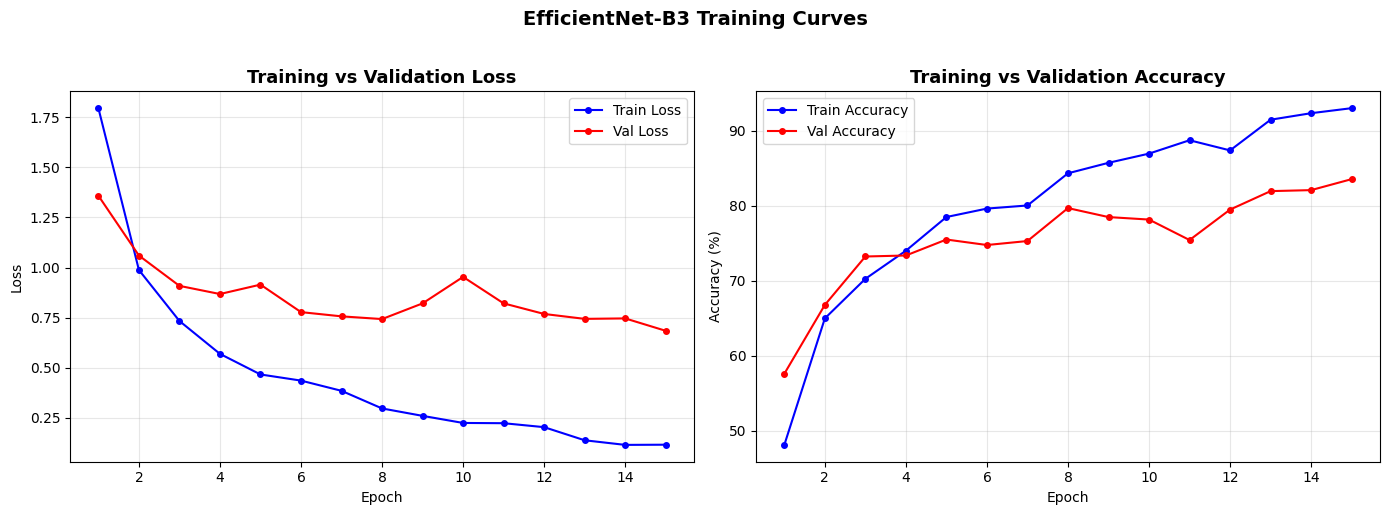

In [9]:
# Plot training curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, 16)

# Loss curves
ax1.plot(epochs_range, train_losses, 'b-o', label='Train Loss', markersize=4)
ax1.plot(epochs_range, val_losses,   'r-o', label='Val Loss',   markersize=4)
ax1.set_title('Training vs Validation Loss', fontsize=13, fontweight='bold')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy curves
ax2.plot(epochs_range, train_accs, 'b-o', label='Train Accuracy', markersize=4)
ax2.plot(epochs_range, val_accs,   'r-o', label='Val Accuracy',   markersize=4)
ax2.set_title('Training vs Validation Accuracy', fontsize=13, fontweight='bold')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.suptitle('EfficientNet-B3 Training Curves', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150, bbox_inches='tight')
plt.show()